# Clase 7: APIs + LLMs — Analizando comentarios de YouTube
### México vs Ecuador, Mundial 2026

---

## ¿Qué vamos a hacer?

Vamos a construir un pipeline completo de análisis de texto en tres pasos:

1. **Descargar** comentarios del video oficial de México vs Ecuador en YouTube usando la YouTube Data API
2. **Limpiar y organizar** los datos con `pandas`
3. **Clasificar automáticamente** cada comentario con un modelo de lenguaje (LLM) de Hugging Face

Al final vamos a poder responder preguntas como: ¿cuántos comentarios son de celebración vs crítica? ¿Los comentarios más likeados son más emocionales o más analíticos?

## Herramientas que usamos

| Herramienta | Para qué |
|---|---|
| **YouTube Data API v3** | Descargar comentarios de cualquier video público |
| **pandas** | Organizar, limpiar y analizar los datos |
| **Hugging Face Transformers** | Clasificar texto con un LLM pre-entrenado |
| **matplotlib** | Visualizar los resultados |

## ¿Qué es zero-shot classification?

Un modelo de clasificación tradicional necesita miles de ejemplos etiquetados para aprender: *"este comentario es celebración"*, *"este es crítica"*. Tienes que etiquetar datos a mano antes de poder usarlo.

**Zero-shot** significa que el modelo clasifica texto en categorías que **nunca vio durante el entrenamiento**. Le dices las categorías en el momento, y el modelo usa su comprensión del lenguaje para decidir. Cero ejemplos, cero entrenamiento.

El modelo que usamos es `facebook/bart-large-mnli`. Fue entrenado en NLI (Natural Language Inference) — aprender si una hipótesis se sigue de una premisa. La clasificación zero-shot reformula cada categoría como una hipótesis: *"este texto es una celebración"* → ¿verdadero o falso?

## Importante: antes de empezar

Este notebook usa **GPU de Google Colab** para correr el modelo localmente. Antes de ejecutar cualquier celda:

1. Ve a **Runtime → Change runtime type → T4 GPU**
2. Guarda tu YouTube API key en **Secrets** (🔑 en la barra izquierda) con el nombre `YOUTUBE_API_KEY`

---
## Paso 1 — Instalación de librerías

In [3]:
%%capture
# %%capture suprime todo el output de esta celda
# útil para instalaciones que generan mucho texto irrelevante
!pip install google-api-python-client transformers torch pandas matplotlib

---
## Paso 2 — Importar librerías y configurar credenciales

In [4]:
# ── Importar librerías ────────────────────────────────────────────────────────
# En Python, antes de usar cualquier librería hay que importarla explícitamente
# Es buena práctica poner todos los imports al inicio del notebook

import pandas as pd                          # manipulación de datos — el dplyr/tidyverse de Python
import matplotlib.pyplot as plt             # gráficas — equivale a ggplot2 pero más manual
import torch                                 # librería de deep learning — necesaria para la GPU
from google.colab import userdata            # para leer los Secrets de Colab
from googleapiclient.discovery import build  # cliente oficial para las APIs de Google
from transformers import pipeline            # para cargar y usar modelos de Hugging Face

print("Librerías importadas ✓")

Librerías importadas ✓


In [5]:
# ── Verificar que la GPU está activa ─────────────────────────────────────────
# torch.cuda.is_available() devuelve True si hay GPU disponible
# Si devuelve False, ve a Runtime → Change runtime type → T4 GPU

print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No hay GPU — el modelo va a ser muy lento. Cambia el runtime.")

GPU disponible: True
GPU: Tesla T4


In [6]:
# ── Cargar credenciales desde Secrets ────────────────────────────────────────
# userdata.get('nombre') lee el valor del Secret con ese nombre
# NUNCA pongas la key directamente en el código — si subes el notebook a GitHub
# cualquiera podría ver tu key y usarla

YOUTUBE_API_KEY = userdata.get('YOUTUBE_API_KEY')

# El ID del video está en la URL después de ?v=
# https://www.youtube.com/watch?v=iCFwyDKzihA
#                                  ↑ este es el ID
VIDEO_ID = "iCFwyDKzihA"

print("Credenciales cargadas ✓")

Credenciales cargadas ✓


---
## Paso 3 — Cargar el modelo de clasificación

Antes de descargar los comentarios, cargamos el modelo. Tarda 1 minuto porque descarga los pesos del modelo desde Hugging Face (~1.6 GB). Solo hay que hacerlo una vez por sesión.

In [7]:
# pipeline() es una función de Hugging Face que empaqueta todo lo necesario
# para usar un modelo: tokenizador + modelo + post-procesamiento
#
# "zero-shot-classification" = tipo de tarea que queremos hacer
# model = el modelo que usamos (bart-large-mnli = BART entrenado en NLI)
# device = 0 → usar la primera GPU disponible
# device = -1 → usar CPU (mucho más lento)

print("Cargando modelo... (puede tardar ~1 minuto)")

clasificador = pipeline(
    "zero-shot-classification",
    model  = "facebook/bart-large-mnli",
    device = 0
)

print("Modelo cargado en GPU ✓")

Cargando modelo... (puede tardar ~1 minuto)


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Modelo cargado en GPU ✓


---
## Paso 4 — Descargar comentarios de YouTube

### ¿Qué es una API?

Una API (Application Programming Interface) es un servicio que un servidor ofrece para que otros programas puedan pedirle datos de forma estructurada. En vez de scrapear el HTML de YouTube — que es complicado y puede romperse cuando YouTube cambia su diseño — usamos la API oficial que Google ofrece.

El flujo siempre es el mismo:
1. **Construir** la petición: qué quieres, con qué parámetros, con tu key para autenticarte
2. **Ejecutar** la petición: mandarla al servidor de Google
3. **Parsear** la respuesta: el servidor devuelve un JSON — hay que navegarlo para extraer los datos

### ¿Qué es un JSON?

JSON (JavaScript Object Notation) es el formato más común para intercambiar datos entre programas. Se parece mucho a un diccionario de Python:

```json
{
  "autor": "Juan",
  "texto": "¡Viva México!",
  "likes": 42
}
```

La YouTube API devuelve un JSON con muchos niveles anidados. Hay que navegar esa estructura para llegar al texto del comentario.

In [8]:
# build() crea el cliente de la API de YouTube
# 'youtube'    = nombre del servicio en Google
# 'v3'         = versión de la API
# developerKey = nuestra key para que Google sepa quién pregunta

youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)

print("Cliente de YouTube creado ✓")

Cliente de YouTube creado ✓


In [14]:
# Antes de escribir la función completa, veamos cómo se ve
# la respuesta cruda de la API para entender la estructura del JSON
#
# La API de YouTube devuelve los datos como un diccionario anidado.
# Para llegar al texto de un comentario hay que navegar varios niveles.
# Esta celda nos muestra esa estructura antes de ocultarla dentro de una función.

peticion_prueba = youtube.commentThreads().list(
    part       = 'snippet',   # 'snippet' le dice a la API qué información queremos
                               # sin esto la API no sabe si queremos el texto,
                               # las estadísticas, los replies, etc.
    videoId    = VIDEO_ID,
    maxResults = 2             # solo 2 para ver la estructura sin inundarnos de datos
)

# .execute() es lo que realmente manda la petición a Google
# hasta este momento solo hemos construido la petición, no la hemos enviado
respuesta_prueba = peticion_prueba.execute()

# ── Nivel 1: el diccionario raíz ──────────────────────────────────────────────
# la respuesta completa es un diccionario con estas claves:
# 'kind'          → tipo de objeto (siempre "youtube#commentThreadListResponse")
# 'etag'          → versión de los datos (para caché)
# 'nextPageToken' → token para pedir la siguiente página de comentarios
# 'pageInfo'      → cuántos resultados hay en total
# 'items'         → la lista de comentarios — esto es lo que nos interesa
print("Nivel 1 — Claves del JSON raíz:")
print(list(respuesta_prueba.keys()))

# ── Nivel 2: un item (un hilo de comentario) ──────────────────────────────────
# 'items' es una lista — cada elemento es un hilo de comentario
# un hilo = el comentario principal + sus respuestas
# items[0] es el primer hilo (el más relevante según YouTube)
print("\nNivel 2 — Claves de items[0] (un hilo de comentario):")
print(list(respuesta_prueba['items'][0].keys()))
# 'kind'    → tipo ("youtube#commentThread")
# 'etag'    → versión
# 'id'      → ID único del hilo
# 'snippet' → el contenido — aquí está lo importante

# ── Nivel 3 y 4: navegar hasta el texto ───────────────────────────────────────
# items[0]
#   └── 'snippet'                   (info del hilo)
#         └── 'topLevelComment'     (el comentario principal, sin las respuestas)
#               └── 'snippet'       (el contenido del comentario)
#                     └── 'textDisplay'  (el texto que escribió el usuario)
print("\nTexto del primer comentario (navegando 4 niveles):")
print(respuesta_prueba['items'][0]['snippet']['topLevelComment']['snippet']['textDisplay'])

Nivel 1 — Claves del JSON raíz:
['kind', 'etag', 'nextPageToken', 'pageInfo', 'items']

Nivel 2 — Claves de items[0] (un hilo de comentario):
['kind', 'etag', 'id', 'snippet']

Texto del primer comentario (navegando 4 niveles):
Dónde están los ecuatorianas? 😂😂Perdón los ecuatorianos solo sirvieron para llorar y buscar pretextos para disimular la vergüenza de su disque mejor defensa del mundo , cuando un morro de 17 años los hizo mierda, viva México p.... 🇲🇽💯


In [15]:
def descargar_comentarios(video_id, max_comentarios=200):
    """
    Descarga comentarios de un video de YouTube.

    YouTube no manda todos los comentarios de una vez — los pagina
    en bloques de máximo 100. Esta función maneja esa paginación
    automáticamente hasta llegar a max_comentarios.

    Parámetros:
        video_id        : ID del video (lo que va después de ?v= en la URL)
        max_comentarios : cuántos descargar en total

    Retorna:
        Lista de diccionarios, uno por comentario
    """
    comentarios = []    # lista vacía donde acumulamos los resultados
    page_token  = None  # token de paginación — None significa "primera página"

    # el while corre mientras no tengamos suficientes comentarios
    while len(comentarios) < max_comentarios:

        # construimos la petición
        peticion = youtube.commentThreads().list(
            part       = 'snippet',
            videoId    = video_id,
            # min() para no pedir más de lo que necesitamos en la última página
            maxResults = min(100, max_comentarios - len(comentarios)),
            order      = 'relevance',  # los más relevantes primero
            pageToken  = page_token    # None en la primera vuelta, luego el token
        )

        # ejecutamos la petición — aquí es cuando realmente llamamos a Google
        respuesta = peticion.execute()

        # iteramos sobre los comentarios de esta página
        for item in respuesta['items']:
            # navegamos la estructura anidada del JSON
            # item → snippet → topLevelComment → snippet → datos
            snippet = item['snippet']['topLevelComment']['snippet']

            # guardamos solo lo que nos interesa en un diccionario limpio
            comentarios.append({
                'texto'     : snippet['textDisplay'],
                'autor'     : snippet['authorDisplayName'],
                'likes'     : snippet['likeCount'],
                'fecha'     : snippet['publishedAt'],
                'respuestas': item['snippet']['totalReplyCount']
            })

        # .get() devuelve None si la clave no existe — no da error
        # si no hay nextPageToken, es la última página y salimos del while
        page_token = respuesta.get('nextPageToken')
        if not page_token:
            break

    print(f"Descargados {len(comentarios)} comentarios ✓")
    return comentarios


comentarios_raw = descargar_comentarios(VIDEO_ID, max_comentarios=500)

Descargados 500 comentarios ✓


---
## Paso 5 — Organizar y limpiar con pandas

`pandas` es la librería de manipulación de datos de Python. Su estructura central es el **DataFrame** — una tabla con filas y columnas, igual que el data frame de R. La mayoría de las operaciones de tidyverse tienen un equivalente en pandas.

In [16]:
# pd.DataFrame() convierte una lista de diccionarios en un DataFrame
# cada diccionario se vuelve una fila
# las claves del diccionario se vuelven las columnas
# equivale a data.frame() o tibble() en R

df = pd.DataFrame(comentarios_raw)

print(f"Dimensiones: {df.shape}")  # (filas, columnas) — equivale a dim() en R
df.head()                           # primeras 5 filas — equivale a head() en R

Dimensiones: (500, 5)


,texto,autor,likes,fecha,respuestas
0,Mexicanos es un honor presenciar esto con uste...,@AngelMãløt3,6147,2026-07-01T04:16:00Z,60
1,"Después de todo lo que paso Raúl Jiménez, verl...",@jbomts,4274,2026-07-01T04:12:17Z,35
2,"A mis 75 años, veo a la selección de mi México...",@marioeusebiobenitez746,1421,2026-07-01T11:28:25Z,26
3,Quiñones eres un bendito orgullo nacional,@xanthippus3190,4290,2026-07-01T04:13:18Z,64
4,"A celebrar Pero mañana... Cabeza fría, humilda...",@SenorX-bn4wt,1335,2026-07-01T04:50:02Z,6


In [17]:
# dtypes muestra el tipo de cada columna — equivale a glimpse() en R
# object = texto (string), int64 = entero, float64 = decimal
df.dtypes

,0
texto,object
autor,object
likes,int64
fecha,object
respuestas,int64


In [18]:
# ── Limpieza de datos ─────────────────────────────────────────────────────────

# 1. Convertir fecha de texto a datetime
# viene como string '2026-06-30T22:15:03.000Z'
# pd.to_datetime() lo convierte a un tipo fecha que pandas entiende
# equivale a as.Date() o as_datetime() en R
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Limpiar el texto de los comentarios
# YouTube mete tags HTML dentro del texto: <br> para saltos de línea,
# &amp; para el símbolo &, &#39; para la comilla apostrofe, etc.
# .str. permite aplicar funciones de texto a toda la columna a la vez
# equivale a mutate(texto = str_replace(...)) en R
df['texto_limpio'] = (
    df['texto']
    .str.replace('<br>', ' ', regex=False)    # salto de línea HTML → espacio
    .str.replace('&amp;', '&', regex=False)   # entidad HTML → símbolo real
    .str.replace('&#39;', "'", regex=False)   # comilla HTML → comilla real
    .str.strip()                               # quitar espacios al inicio y al final
)

# 3. Filtrar comentarios muy cortos — no aportan información al clasificador
# df[condicion] filtra filas donde la condición es True
# equivale a filter() en R
# .str.len() cuenta cuántos caracteres tiene cada texto
# .reset_index(drop=True) reordena los índices después de filtrar
# (sin esto los índices quedarían con huecos: 0, 3, 7, 12...)
df = df[df['texto_limpio'].str.len() >= 15].reset_index(drop=True)

print(f"Comentarios después de limpiar: {len(df)}")
df[['texto_limpio', 'likes', 'respuestas']].head(8)

Comentarios después de limpiar: 472


,texto_limpio,likes,respuestas
0,Mexicanos es un honor presenciar esto con uste...,6147,60
1,"Después de todo lo que paso Raúl Jiménez, verl...",4274,35
2,"A mis 75 años, veo a la selección de mi México...",1421,26
3,Quiñones eres un bendito orgullo nacional,4290,64
4,"A celebrar Pero mañana... Cabeza fría, humilda...",1335,6
5,Fue un partido muy bonito porque mi Papá tiene...,461,11
6,Un chico de 17 años que juega en Xolos de Tiju...,2959,42
7,QUE JUEGAZO SE MANDO GILBERTO MORA 🔥❤️ un orgu...,2155,47


In [19]:
# Exploración rápida antes de clasificar

# .describe() da estadísticos de todas las columnas numéricas
# equivale a summary() en R
print("Estadísticos de likes:")
print(df['likes'].describe())

print(f"\nComentario con más likes:")
# .idxmax() devuelve el ÍNDICE de la fila con el valor máximo
# .loc[idx, columna] accede a una celda específica por índice y nombre de columna
idx_max = df['likes'].idxmax()
print(f"'{df.loc[idx_max, 'texto_limpio']}' ({df.loc[idx_max, 'likes']} likes)")

Estadísticos de likes:
count     472.000000
mean       85.819915
std       462.049468
min         0.000000
25%         0.000000
50%         1.000000
75%         7.250000
max      6147.000000
Name: likes, dtype: float64

Comentario con más likes:
'Mexicanos es un honor presenciar esto con ustedes hermanos viva México alv' (6147 likes)


---
## Paso 6 — Clasificación zero-shot

### Las categorías

Usamos categorías en **inglés** aunque los comentarios sean en español. El modelo fue entrenado principalmente en inglés y funciona mejor cuando las etiquetas están en ese idioma — el texto a clasificar puede estar en cualquier idioma.

### ¿Cómo funciona `pipeline` con GPU?

Cuando cargamos el modelo con `device=0`, Hugging Face lo pone en la memoria de la GPU. Cuando le pasamos texto, la GPU procesa las operaciones matemáticas en paralelo — por eso es tan rápido comparado con la CPU.

La función `clasificador()` recibe el texto y una lista de categorías, y devuelve un diccionario con los scores de cada categoría.

In [30]:
# Categorías en inglés — el modelo fue entrenado en inglés
# aunque los comentarios sean en español, las etiquetas deben ser en inglés
CATEGORIAS = [
    "celebration or joy",
    "criticism or complaint",
    "mockery or sarcasm",
    "tactical analysis",
    "spam or advertisement"
]

In [31]:
# Probar con UN solo comentario antes del loop completo
# siempre hay que verificar que el modelo funciona antes de procesar todo

comentario_prueba = "Que felicidad por fin ganamos un partido de eliminacion directa"

# clasificador() recibe el texto y las categorías
# devuelve un diccionario con 'labels' y 'scores'
# 'labels' = lista de categorías ordenadas de mayor a menor score
# 'scores' = lista de scores en el mismo orden
resultado = clasificador(comentario_prueba, CATEGORIAS)

print(f"Comentario: '{comentario_prueba}'")
print(f"\nScores por categoría:")
for label, score in zip(resultado['labels'], resultado['scores']):
    # zip() une dos listas elemento por elemento
    # equivale a iterar sobre dos vectores en paralelo
    barra = '█' * int(score * 30)   # barra visual proporcional al score
    print(f"  {label:<25} {score:.3f} {barra}")

# el primer elemento ya es el de mayor score
print(f"\n→ Categoría asignada: {resultado['labels'][0]}")

Comentario: 'Que felicidad por fin ganamos un partido de eliminacion directa'

Scores por categoría:
  this is celebration, happiness or pride about the result 0.943 ████████████████████████████
  this is a tactical or strategic football analysis 0.029 
  this is mockery, sarcasm or jokes about the losing team 0.013 
  this is criticism of players, coaching or performance 0.012 
  this is spam, promotion or irrelevant content 0.004 

→ Categoría asignada: this is celebration, happiness or pride about the result


In [32]:
# Clasificar todos los comentarios con GPU — sin time.sleep() porque
# el modelo corre localmente, no hay rate limit de API que respetar

N = min(200, len(df))          # procesar todos, hasta 200
df_muestra = df.head(N).copy() # .copy() para no modificar el DataFrame original

categorias_asignadas = []  # lista donde acumulamos las categorías
scores_asignados     = []  # lista donde acumulamos los scores

print(f"Clasificando {N} comentarios con GPU...")

for i, texto in enumerate(df_muestra['texto_limpio']):
    # enumerate(serie) devuelve pares (índice, valor)
    # i = índice de la fila (0, 1, 2...)
    # texto = el contenido de la celda

    resultado = clasificador(texto, CATEGORIAS)

    categorias_asignadas.append(resultado['labels'][0])
    scores_asignados.append(resultado['scores'][0])

    # mostrar progreso cada 20 comentarios
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{N} procesados...")

# agregar las columnas nuevas al DataFrame
# df['nueva_columna'] = lista crea una columna nueva
# equivale a mutate() en R
df_muestra['categoria'] = categorias_asignadas
df_muestra['score']     = scores_asignados

print(f"\n¡Listo! {N} comentarios clasificados ✓")
df_muestra[['texto_limpio', 'categoria', 'score']].head(10)

Clasificando 200 comentarios con GPU...
  20/200 procesados...
  40/200 procesados...
  60/200 procesados...
  80/200 procesados...
  100/200 procesados...
  120/200 procesados...
  140/200 procesados...
  160/200 procesados...
  180/200 procesados...
  200/200 procesados...

¡Listo! 200 comentarios clasificados ✓


,texto_limpio,categoria,score
0,Mexicanos es un honor presenciar esto con uste...,"this is celebration, happiness or pride about ...",0.979369
1,"Después de todo lo que paso Raúl Jiménez, verl...","this is celebration, happiness or pride about ...",0.969403
2,"A mis 75 años, veo a la selección de mi México...","this is celebration, happiness or pride about ...",0.916875
3,Quiñones eres un bendito orgullo nacional,"this is celebration, happiness or pride about ...",0.958099
4,"A celebrar Pero mañana... Cabeza fría, humilda...","this is celebration, happiness or pride about ...",0.963800
5,Fue un partido muy bonito porque mi Papá tiene...,"this is celebration, happiness or pride about ...",0.921765
6,Un chico de 17 años que juega en Xolos de Tiju...,"this is mockery, sarcasm or jokes about the lo...",0.617920
7,QUE JUEGAZO SE MANDO GILBERTO MORA 🔥❤️ un orgu...,"this is celebration, happiness or pride about ...",0.968607
8,"Qué les costaba jugar así ,años sin ver esta ...","this is criticism of players, coaching or perf...",0.479826
9,"40 años de no ganar eliminatorias, esto ya es ...","this is celebration, happiness or pride about ...",0.846578


---
## Paso 7 — Análisis y visualización

In [33]:
# ── Distribución de categorías ────────────────────────────────────────────────
# .value_counts() cuenta cuántos hay de cada valor único en una columna
# equivale a count() en tidyverse
conteo = df_muestra['categoria'].value_counts()

print("Comentarios por categoría:")
print(conteo)
print(f"\nPorcentajes:")
# dividimos entre el total y multiplicamos por 100
print((conteo / len(df_muestra) * 100).round(1))

Comentarios por categoría:
categoria
this is celebration, happiness or pride about the result    161
this is mockery, sarcasm or jokes about the losing team      30
this is criticism of players, coaching or performance         9
Name: count, dtype: int64

Porcentajes:
categoria
this is celebration, happiness or pride about the result    80.5
this is mockery, sarcasm or jokes about the losing team     15.0
this is criticism of players, coaching or performance        4.5
Name: count, dtype: float64


In [35]:
print(df_muestra['categoria'].value_counts())

categoria
this is celebration, happiness or pride about the result    161
this is mockery, sarcasm or jokes about the losing team      30
this is criticism of players, coaching or performance         9
Name: count, dtype: int64


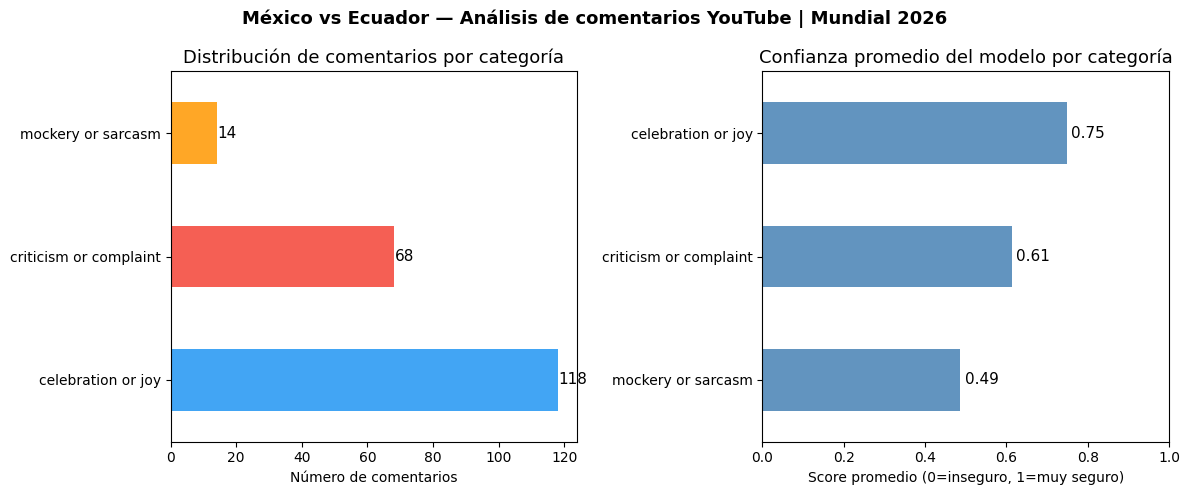

In [27]:
# ── Gráficas ──────────────────────────────────────────────────────────────────

# plt.subplots(1, 2) crea una figura con 1 fila y 2 columnas de paneles
# figsize=(12, 5) es el tamaño total en pulgadas
# axes es un array con los dos paneles — axes[0] es el izquierdo, axes[1] el derecho
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colores = ['#2196F3', '#F44336', '#FF9800', '#4CAF50', '#9E9E9E']

# ── Panel izquierdo: distribución de categorías ───────────────────────────────
# .plot(kind='barh') hace barras horizontales
# ax=axes[0] indica en cuál panel dibujar
conteo.plot(kind='barh', ax=axes[0], color=colores, alpha=0.85)
axes[0].set_title('Distribución de comentarios por categoría', fontsize=13)
axes[0].set_xlabel('Número de comentarios')
axes[0].set_ylabel('')

# agregar etiquetas numéricas al final de cada barra
for i, v in enumerate(conteo.values):
    # axes[0].text(x, y, texto) escribe texto en coordenadas (x, y)
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=11)

# ── Panel derecho: confianza del modelo por categoría ────────────────────────
# .groupby('categoria')['score'].mean() agrupa por categoría y calcula el promedio
# equivale a group_by(categoria) %>% summarise(mean(score)) en R
confianza_por_cat = df_muestra.groupby('categoria')['score'].mean().sort_values()

confianza_por_cat.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.85)
axes[1].set_title('Confianza promedio del modelo por categoría', fontsize=13)
axes[1].set_xlabel('Score promedio (0=inseguro, 1=muy seguro)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1)

for i, v in enumerate(confianza_por_cat.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=11)

# plot_annotation general para toda la figura
fig.suptitle('México vs Ecuador — Análisis de comentarios YouTube | Mundial 2026',
             fontsize=13, fontweight='bold')

plt.tight_layout()  # ajusta márgenes para que nada se corte
plt.show()

In [28]:
# ── ¿Los comentarios más likeados son más emocionales o más analíticos? ───────
# Pregunta interesante: ¿la gente da más likes al contenido emocional
# (celebración, burla) o al analítico?

# .groupby().agg() permite calcular varias estadísticas a la vez
# equivale a group_by() %>% summarise(mean=mean(x), sum=sum(x)) en R
likes_por_cat = (
    df_muestra
    .groupby('categoria')['likes']
    .agg(['mean', 'sum', 'count'])
    .round(1)
    .sort_values('mean', ascending=False)
)
likes_por_cat.columns = ['likes_promedio', 'likes_total', 'n_comentarios']

print("Likes por categoría:")
print(likes_por_cat)

Likes por categoría:
                        likes_promedio  likes_total  n_comentarios
categoria                                                         
mockery or sarcasm               241.9         3387             14
celebration or joy               232.1        27383            118
criticism or complaint           139.6         9496             68


In [29]:
# ── Top 5 comentarios más likeados con su categoría ──────────────────────────
# .sort_values('likes', ascending=False) ordena de mayor a menor
# equivale a arrange(desc(likes)) en R

top5 = (
    df_muestra
    .sort_values('likes', ascending=False)
    .head(5)
    [['texto_limpio', 'likes', 'categoria', 'score']]
)

print("Top 5 comentarios más likeados:\n")

# .iterrows() itera fila por fila devolviendo (índice, fila)
# equivale a un for sobre las filas de un data frame
for _, fila in top5.iterrows():
    print(f"[{fila['likes']} likes | {fila['categoria']} | confianza: {fila['score']:.2f}]")
    print(f"  {fila['texto_limpio'][:120]}")
    print()

Top 5 comentarios más likeados:

[6147 likes | celebration or joy | confianza: 0.94]
  Mexicanos es un honor presenciar esto con ustedes hermanos viva México alv

[4290 likes | celebration or joy | confianza: 0.92]
  Quiñones eres un bendito orgullo nacional

[4274 likes | celebration or joy | confianza: 0.95]
  Después de todo lo que paso Raúl Jiménez, verlo disfrutando y anotando me hace Feliz 🇲🇽⚽️⚽️

[2959 likes | mockery or sarcasm | confianza: 0.52]
  Un chico de 17 años que juega en Xolos de Tijuana les metió un bailé a un campeón de mundial de clubes, un campeón de pr

[2155 likes | celebration or joy | confianza: 0.91]
  QUE JUEGAZO SE MANDO GILBERTO MORA 🔥❤️ un orgullo tener a ese jugador en la selección



---
## El mismo código, cualquier video

Para analizar otro video solo cambias dos cosas: el `VIDEO_ID` y las `CATEGORIAS`. El resto del código es idéntico.

```python
# Reseñas de un restaurante
VIDEO_ID   = "ID_DEL_VIDEO"
CATEGORIAS = ["positive experience", "negative experience",
              "question about the place", "spam"]

# Comentarios de un video político
CATEGORIAS = ["support", "criticism", "neutral analysis",
              "misinformation", "spam"]

# Reseñas de un producto
CATEGORIAS = ["satisfied", "unsatisfied", "shipping problem",
              "price quality ratio", "spam"]
```

**El modelo no necesita reentrenamiento.** Eso es el poder del zero-shot.